In [93]:
"""
Full-band CFR demo – Python 3.11 · TF 2.19 · Sionna 1.0.2
"""

# --------------------------------------------------------------------#
# 0) Imports & GPU housekeeping
# --------------------------------------------------------------------#
import os, numpy as np, matplotlib.pyplot as plt, tensorflow as tf
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

try:
    import sionna, sionna.rt
except ImportError:
    os.system("pip install -q --upgrade sionna")
    import sionna, sionna.rt

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, PathSolver, subcarrier_frequencies

# Other imports          
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import sys
    
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, watt_to_dbm

from sionna.phy.channel import OFDMChannel, CIRDataset
from sionna.phy.nr import PUSCHConfig, PUSCHTransmitter, PUSCHReceiver
from sionna.phy.utils import ebnodb2no, PlotBER
from sionna.phy.ofdm import KBestDetector, LinearDetector
from sionna.phy.mimo import StreamManagement

# Import Sionna RT components
from sionna.rt import load_scene, Camera, Transmitter, Receiver, PlanarArray,\
                      PathSolver, RadioMapSolver
import random


In [94]:
scene = load_scene(sionna.rt.scene.munich) # Load empty scene

# Configure antenna arrays for all transmitters and receivers
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,  # relative to wavelength
                             horizontal_spacing=0.5,  # relative to wavelength
                             pattern="iso",
                             polarization="V")
scene.rx_array = scene.tx_array

# Remove transmitters here so that the cell can be executed multiple times
scene.remove("tx0")
scene.remove("tx1")
scene.remove("tx2")
scene.remove("jam1")
scene.remove("jam2")

# Define and add a first transmitter to the scene
tx0 = Transmitter(name='tx0',
                  position=[-100, -100, 20],
                  orientation=[np.pi*5/6, 0, 0],
                  power_dbm=30)
scene.add(tx0)

tx1 = Transmitter(name='tx1',
                  position=[-100, 50, 20],
                  orientation=[np.pi/6, 0, 0],
                  power_dbm=30)
scene.add(tx1)

tx2 = Transmitter(name='tx2',
                  position=[100, -100, 20],
                  orientation=[-np.pi/2, 0, 0],
                  power_dbm=30)
scene.add(tx2)


tx3 = Transmitter(name='jam1',
                  position=[-50, -50, 20],
                  orientation=[np.pi/6, 0, 0],
                  power_dbm=200)
scene.add(tx3)

tx4 = Transmitter(name='jam2',
                  position=[50, 100, 20],
                  orientation=[-np.pi/2, 0, 0],
                  power_dbm=200)
scene.add(tx4)

rx   = Receiver   ("rx",     [0,   0,  20])
scene.add(rx)
rm_solver = RadioMapSolver()
rm = rm_solver(scene,
               max_depth=5,
               cell_size=(1., 1.),
               samples_per_tx=10**7)


Shape of H: (5, 1024)


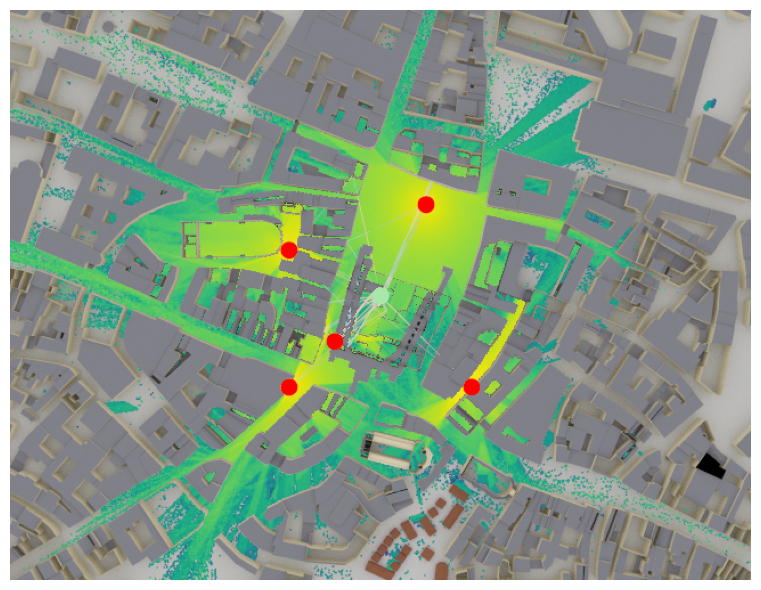

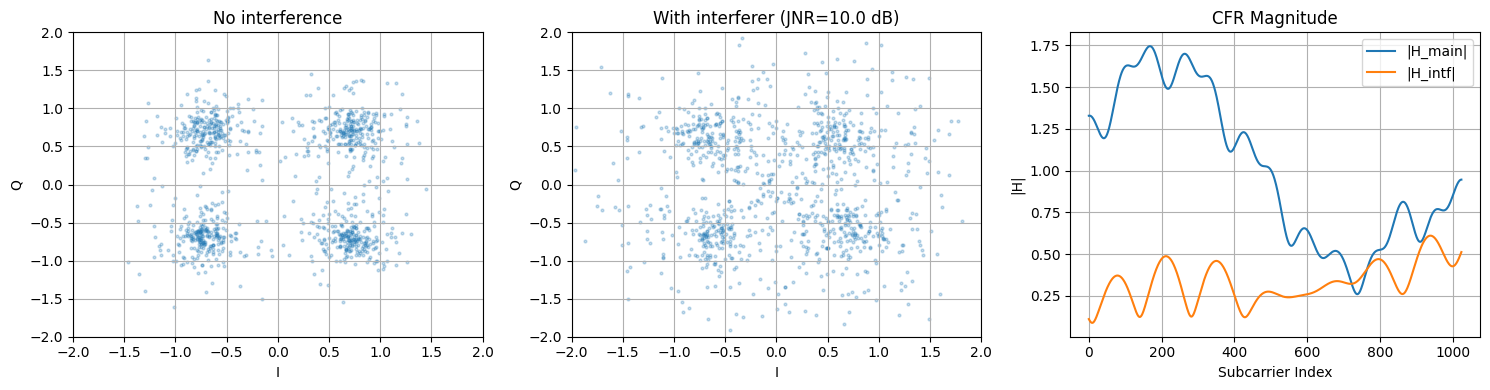

In [95]:
solver = PathSolver()
def solve():
    return solver(scene,
                  max_depth=6, los=True,
                  specular_reflection=True,
                  refraction=True)

# --------------------------------------------------------------------#
# 2) OFDM parameters & CFR
# --------------------------------------------------------------------#
Nsc = 1024         # 子載波數
Δf  = 30e3         # 子載波間隔 30 kHz
fc  = scene.frequency
# 取回所有子載波頻率
freqs = subcarrier_frequencies(Nsc, Δf)

paths = solve()
# 取回 CFR 並 squeeze → shape = (num_tx=2, Nsc)
H = paths.cfr(frequencies=freqs,
              normalize=True,
              normalize_delays=True,
              out_type="numpy").squeeze()
print("Shape of H:", H.shape)  # => (2, 1024)

# 直接用 2 維切片
          # 主 Tx → Rx
h_main = np.sum(H[0:3, :], axis=0)
h_intf = np.sum(H[3:5, :], axis=0)


# --------------------------------------------------------------------#
# 3) 生成 QPSK-OFDM 符號
# --------------------------------------------------------------------#
Nsym = 1
bits = np.random.randint(0, 2, (Nsym, Nsc, 2))
X    = (1 - 2*bits[...,0] + 1j*(1-2*bits[...,1]))/np.sqrt(2)  # QPSK

# 直接在頻域作通道作用
Y_sig = X * h_main[np.newaxis, :]
Y_int = X * h_intf[np.newaxis, :]

# JNR & Eb/N0
JNRdB, EbN0dB = 10.0, 10.0
p_sig = np.mean(np.abs(Y_sig)**2)
p_int = np.mean(np.abs(Y_int)**2)
scale = 0.0 if not np.any(h_intf) else np.sqrt(p_sig/p_int/10**(JNRdB/10))
Y_int *= scale
N0    = p_sig/(10**(EbN0dB/10)*2)
noise = np.sqrt(N0/2)*(np.random.randn(*Y_sig.shape)+1j*np.random.randn(*Y_sig.shape))

Y_tot = Y_sig + Y_int + noise

y_no_i   = Y_sig + noise
y_with_i = Y_sig + Y_int + noise

# perfect equalisation
y_eq_no_i   = y_no_i   / h_main
y_eq_with_i = y_with_i / h_main

# --------------------------------------------------------------------#
# 4) 頻域等化 (Zero-Forcing per-subcarrier)
# --------------------------------------------------------------------#
X_hat = Y_tot / h_main[np.newaxis, :]

# --------------------------------------------------------------------#
# 5) 繪圖：中央子載波星座 & CFR 幅度
# --------------------------------------------------------------------#
k = Nsc//2

my_cam = Camera(position=[0,0,1000], look_at=[0,1,0])
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512, paths=paths, radio_map=rm ,clip_at=20); # Increase num_samples to increase image quality


plt.show()


fig, ax = plt.subplots(1, 3, figsize=(15,4))
ax[0].scatter(y_eq_no_i.real,   y_eq_no_i.imag,   s=4, alpha=.25)
ax[1].scatter(y_eq_with_i.real, y_eq_with_i.imag, s=4, alpha=.25)
ax[0].set(title="No interference", xlabel="I", ylabel="Q",
          xlim=[-2,2], ylim=[-2,2]); ax[0].grid(True)
ttl = f"With interferer (JNR={JNRdB} dB)" if h_intf.any() else "Interferer absent"
ax[1].set(title=ttl, xlabel="I", ylabel="Q",
          xlim=[-2,2], ylim=[-2,2]); ax[1].grid(True)


# CFR 幅度
ax[2].plot(np.abs(h_main), label="|H_main|")
if np.any(h_intf): ax[2].plot(np.abs(h_intf*scale), label="|H_intf|")
ax[2].set(title="CFR Magnitude", xlabel="Subcarrier Index", ylabel="|H|")
ax[2].grid(True); ax[2].legend()

plt.tight_layout(); plt.show()

(1206, 1476, 3)


/tmp/ipykernel_2005642/3986116618.py:48: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


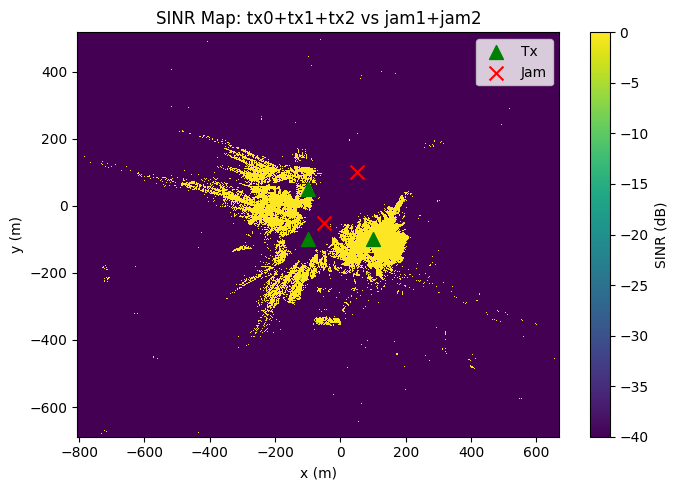

In [96]:
# 1) 获取单元格中心的 x 和 y 坐标
cc       = rm.cell_centers.numpy()    # shape (Ny, Nx, 3)
print(cc.shape)                  # (480, 320, 3)
x_unique = cc[0, :, 0]                # 第一行所有格子中心的 x
y_unique = cc[:, 0, 1]                # 第一列所有格子中心的 y

# 2) 提取前五颗发射机的rss 并转换为 NumPy
rss_list = [rm.rss[i].numpy() for i in range(5)]  # tx0, tx1, tx2
N0 = 1e-12  # 你可以根据实际情况调整

# 3) 计算合并后的 SINR
# rss_list 中分别对应 [tx0, tx1, tx2, jam1, jam2]
rss_desired = rss_list[0] + rss_list[1] + rss_list[2]       # tx0+tx1+tx2 的总接收功率
rss_jammer  = rss_list[3] + rss_list[4]                     # jam1+jam2 的总接收功率



# SINR = desired / (desired + interferers + noise)
sinr = rss_desired / (rss_desired + rss_jammer + N0)

# 如果你想看 dB 形式：
sinr_db = 10 * np.log10(np.clip(sinr, 1e-12, None))


# 4) 绘图
X, Y = np.meshgrid(x_unique, y_unique)
plt.figure(figsize=(7,5))
pcm = plt.pcolormesh(
    X, Y, sinr_db,
    shading='nearest',
    vmin=-40, vmax=0
)
plt.colorbar(pcm, label="SINR (dB)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("SINR Map: tx0+tx1+tx2 vs jam1+jam2")
plt.scatter(
    [tx0.position[0], tx1.position[0], tx2.position[0]],
    [tx0.position[1], tx1.position[1], tx2.position[1]],
    c='g', marker='^', s=100, label='Tx'
)
plt.scatter(
    [tx3.position[0], tx4.position[0]],
    [tx3.position[1], tx4.position[1]],
    c='red',   marker='x', s=100, label='Jam'
)
plt.legend()
plt.tight_layout()
plt.show()
